# Analisis dan Penjelasan Pengolahan Citra pada Proyek Deteksi Pohon Sawit (YOLOv8)

Notebook ini disusun untuk menjelaskan secara rinci alur **pengolahan citra (image processing)** yang diterapkan dalam proyek **Palm Tree Detection (NYAWIT)** berdasarkan referensi berkas `notebook/palmtree_detection.ipynb`.

Pengolahan citra dalam proyek ini dibagi menjadi 4 bagian utama:
1. **Alur Pemrosesan Per-Step untuk Satu Pohon Sawit**
2. **Konversi Format & Struktur Dataset (COCO ke YOLO)**
3. **Augmentasi Data (Albumentations & YOLO Internal)**
4. **Proses Thresholding & Non-Maximum Suppression (NMS)**

## 1. Alur Pemrosesan Per-Step untuk Satu Pohon Sawit

Ketika citra UAV diunggah ke sistem (baik melalui dashboard frontend ke backend REST API, lalu diteruskan ke FastAPI ML Service), citra tersebut melalui beberapa langkah pemrosesan terstruktur sebelum model mendeteksi kondisi kesehatan pohon sawit.

### Diagram Alur Pemrosesan:
1. **Input & Decoding Mode Warna**: Membaca data byte citra dan mendeteksinya. Jika citra bertipe **Grayscale** (1 channel) atau **RGBA** (4 channel/transparansi), sistem akan mengonversinya secara paksa ke format 3 channel **RGB**.
2. **Resize**: Mengubah resolusi citra ke ukuran input standar model YOLOv8 (default: `640x640` piksel).
3. **Normalisasi**: Membagi nilai piksel dengan `255.0` agar bernilai antara `0.0` sampai `1.0` (tipe data Float32), yang membantu stabilitas gradien model.
4. **Inference (Forward Pass)**: Citra diumpankan ke model YOLOv8 untuk memprediksi probabilitas kelas dan koordinat bounding box.
5. **Confidence Thresholding**: Memfilter prediksi bounding box yang memiliki nilai keyakinan di bawah batas threshold (misal: `< 0.55`).
6. **Non-Maximum Suppression (NMS / IoU Thresholding)**: Menghapus bounding box duplikat yang tumpang tindih pada objek pohon sawit yang sama.
7. **Denormalisasi & Klasifikasi Visual**: Mengubah koordinat normalisasi kembali ke dimensi gambar asli untuk digambar dengan label warna sesuai kelas kesehatannya (*Healthy*, *Warning*, atau *Critical*).

In [1]:
%pip install albumentations


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


=== STEP 1: Input & Warna Mode Check ===
Mode warna citra masukan: L (Grayscale, 1 Channel)
-> Berhasil dikonversi ke mode: RGB (3 Channel RGB)

=== STEP 2: Resize & Normalisasi ===
Resolusi citra setelah di-resize: (640, 640)
Tipe Data Array: float32
Skala nilai piksel ternormalisasi: 0.12 s.d 0.55

=== STEP 3: Simulasi Hasil Deteksi Mentah (Inference) ===
Prediksi mentah model: 3 Bounding Box terdeteksi.


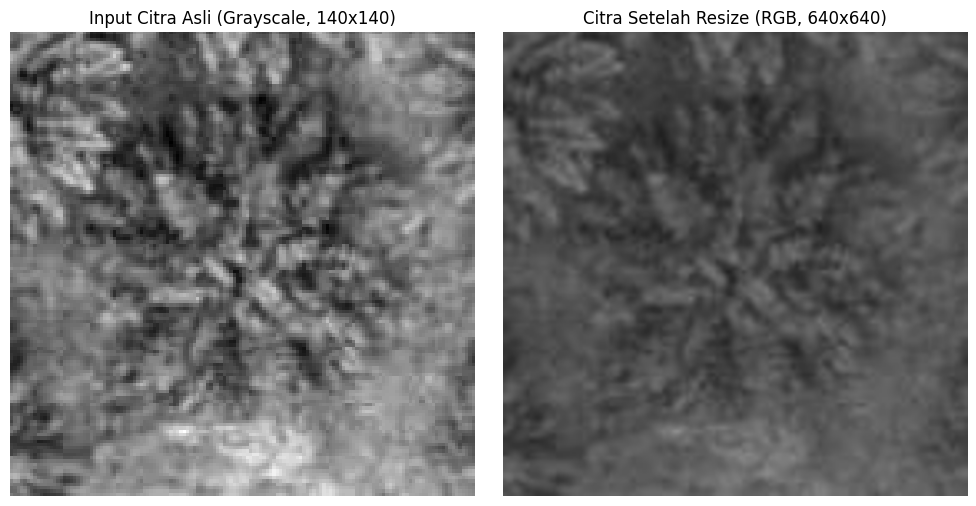

In [2]:
# Simulasi Pemrosesan Step-by-Step Satu Pohon Sawit dalam Kode Python
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

def simulate_palm_processing():
    print("=== STEP 1: Input & Warna Mode Check ===")
    # Membaca citra kelapa sawit asli yang telah dipotong dari dataset
    img_path = "sample_palm.jpg"
    if not os.path.exists(img_path):
        img_path = "notebook/sample_palm.jpg"
        
    pil_image = Image.open(img_path)
    
    # Untuk mensimulasikan penanganan mode warna (Grayscale -> RGB), kita konversi ke Grayscale terlebih dahulu
    raw_gray_image = pil_image.convert('L')
    print(f"Mode warna citra masukan: {raw_gray_image.mode} (Grayscale, 1 Channel)")
    
    # Konversi ke RGB jika bukan RGB (YOLO mengharuskan 3 channel RGB)
    if raw_gray_image.mode != 'RGB':
        pil_image_rgb = raw_gray_image.convert('RGB')
        print(f"-> Berhasil dikonversi ke mode: {pil_image_rgb.mode} (3 Channel RGB)")
    else:
        pil_image_rgb = raw_gray_image
        
    print("\n=== STEP 2: Resize & Normalisasi ===")
    # Mengubah resolusi ke 640x640 sesuai resolusi input model
    resized_image = pil_image_rgb.resize((640, 640))
    print(f"Resolusi citra setelah di-resize: {resized_image.size}")
    
    # Mengonversi ke Float32 dan normalisasi piksel (/ 255.0)
    normalized_array = np.asarray(resized_image, dtype=np.float32) / 255.0
    print(f"Tipe Data Array: {normalized_array.dtype}")
    print(f"Skala nilai piksel ternormalisasi: {normalized_array.min():.2f} s.d {normalized_array.max():.2f}")
    
    print("\n=== STEP 3: Simulasi Hasil Deteksi Mentah (Inference) ===")
    # Model mendeteksi 3 box potensial di sekitar pohon sawit [x1, y1, x2, y2, confidence, class_id]
    # Class 0: Healthy, Class 1: Unhealthy/Dead
    raw_detections = [
        [220, 220, 420, 420, 0.91, 0], # Deteksi A: Box utama di tengah (Akurat)
        [210, 230, 410, 430, 0.85, 0], # Deteksi B: Duplikat box yang tumpang tindih (Overlap)
        [80, 80, 130, 130, 0.22, 0]     # Deteksi C: False positive dengan keyakinan rendah
    ]
    print(f"Prediksi mentah model: {len(raw_detections)} Bounding Box terdeteksi.")
    
    return raw_gray_image, resized_image, raw_detections

raw_gray_img, resized_img, detections = simulate_palm_processing()

# Visualisasi Citra Masukan (Grayscale) dan Citra Setelah di-Resize (RGB)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(raw_gray_img, cmap='gray')
ax[0].set_title(f"Input Citra Asli (Grayscale, {raw_gray_img.width}x{raw_gray_img.height})")
ax[0].axis('off')

ax[1].imshow(resized_img)
ax[1].set_title(f"Citra Setelah Resize (RGB, {resized_img.width}x{resized_img.height})")
ax[1].axis('off')

plt.tight_layout()
plt.show()


## 2. Proses Thresholding & Non-Maximum Suppression (NMS)

Dua proses thresholding sangat penting untuk memastikan hasil deteksi bersih dan akurat:

### A. Confidence Threshold ($T_{conf}$)
Hanya bounding box yang memiliki nilai keyakinan (confidence score) di atas batas tertentu yang akan disimpan. Bounding box dengan keyakinan rendah biasanya merupakan gangguan latar belakang (*false positive*).
$$\text{Keep Box jika } \text{Confidence} \ge T_{conf}$$

### B. Intersection over Union (IoU) & Non-Maximum Suppression (NMS)
Ketika satu pohon sawit dikelilingi oleh banyak bounding box ganda (seperti Deteksi A dan Deteksi B pada simulasi), kita menggunakan algoritma NMS untuk menyaringnya.

#### Rumus IoU:
$$IoU = \frac{\text{Area of Overlap (Irisan)}}{\text{Area of Union (Gabungan)}} = \frac{A \cap B}{A \cup B}$$

#### Langkah Algoritma NMS:
1. Urutkan seluruh bounding box berdasarkan nilai confidence tertinggi.
2. Ambil box dengan confidence tertinggi, simpan sebagai deteksi final.
3. Hitung IoU antara box tersebut dengan box lainnya.
4. Jika $IoU \ge T_{iou}$ (misal IoU melebihi 0.5), maka box lain tersebut dianggap duplikat dan dihapus.
5. Ulangi proses ini untuk box yang tersisa.

In [3]:
# Demonstrasi Implementasi Manual Penapisan (Thresholding) & NMS
def calculate_iou(boxA, boxB):
    # Menentukan koordinat irisan (overlap)
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    
    # Hitung luas area irisan
    interArea = max(0, xB - xA) * max(0, yB - yA)
    
    # Hitung luas masing-masing box
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    
    # Hitung IoU (Area Overlap / Area Union)
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def apply_thresholding_and_nms(raw_boxes, conf_thresh=0.55, iou_thresh=0.5):
    print(f"--- Proses Penapisan dengan Conf Thresh: {conf_thresh} & IoU Thresh: {iou_thresh} ---")
    
    # 1. Terapkan Confidence Threshold
    conf_filtered = [box for box in raw_boxes if box[4] >= conf_thresh]
    print(f"Box lolos Confidence Threshold: {len(conf_filtered)} (Box C dengan conf 0.22 berhasil dibuang)")
    
    # Urutkan berdasarkan confidence tertinggi
    conf_filtered = sorted(conf_filtered, key=lambda x: x[4], reverse=True)
    
    # 2. Terapkan NMS (Non-Maximum Suppression)
    keep_boxes = []
    while conf_filtered:
        best_box = conf_filtered.pop(0)
        keep_boxes.append(best_box)
        
        # Bandingkan dengan sisa box
        remaining_boxes = []
        for box in conf_filtered:
            iou = calculate_iou(best_box[:4], box[:4])
            print(f"Perbandingan Box A dengan Box B -> IoU: {iou:.4f}")
            if iou < iou_thresh:
                remaining_boxes.append(box)
            else:
                print(f"-> Box dengan conf {box[4]} dibuang karena overlap berlebih.")
        conf_filtered = remaining_boxes
        
    return keep_boxes

final_boxes = apply_thresholding_and_nms(detections, conf_thresh=0.55, iou_thresh=0.5)

--- Proses Penapisan dengan Conf Thresh: 0.55 & IoU Thresh: 0.5 ---
Box lolos Confidence Threshold: 2 (Box C dengan conf 0.22 berhasil dibuang)
Perbandingan Box A dengan Box B -> IoU: 0.8223
-> Box dengan conf 0.85 dibuang karena overlap berlebih.


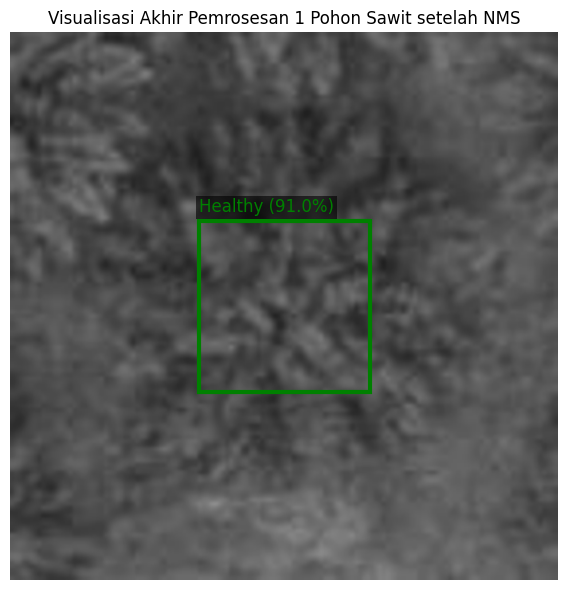

In [4]:
# Visualisasi Hasil Akhir Pemrosesan 1 Pohon Sawit setelah NMS
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(resized_img)
ax.axis('off')

for box in final_boxes:
    x1, y1, x2, y2, conf, cls = box
    color = 'g' if cls == 0 else 'r'
    label = 'Healthy' if cls == 0 else 'Dead/Warning'
    
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=3)
    ax.add_patch(rect)
    ax.text(
        x1, 
        max(0, y1 - 10), 
        f"{label} ({conf*100:.1f}%)", 
        color=color, 
        fontsize=12, 
        bbox=dict(facecolor='black', alpha=0.6, pad=2, edgecolor='none')
    )

plt.title("Visualisasi Akhir Pemrosesan 1 Pohon Sawit setelah NMS", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Konversi Format Koordinat (COCO to YOLO)

Untuk melatih model YOLOv8, anotasi data gambar kelapa sawit harus diubah terlebih dahulu dari koordinat COCO ke YOLO.

### Rumus Konversi:
- $x_{center} = \frac{x_{min} + \frac{width}{2}}{width_{img}}$
- $y_{center} = \frac{y_{min} + \frac{height}{2}}{height_{img}}$
- $w_{norm} = \frac{width}{width_{img}}$
- $h_{norm} = \frac{height}{height_{img}}$

Format COCO: [100, 150, 80, 80]
Format YOLO (Normal): (0.14, 0.19, 0.08, 0.08)


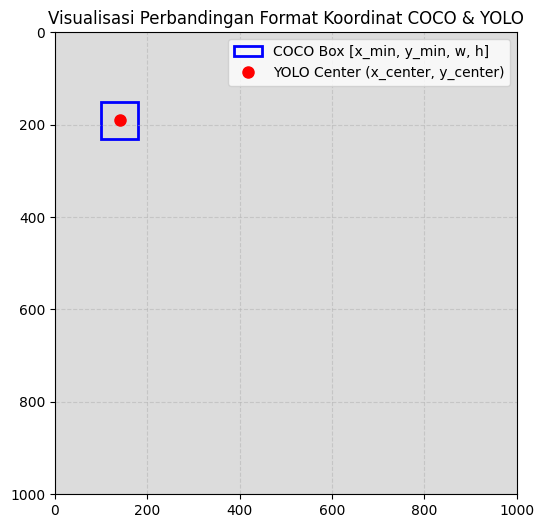

In [5]:
# Demonstrasi konversi COCO ke YOLO dan Visualisasinya
def coco_bbox_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox
    cx = (x + w / 2) / img_w
    cy = (y + h / 2) / img_h
    return cx, cy, w / img_w, h / img_h

img_w, img_h = 1000, 1000
coco_box = [100, 150, 80, 80] # Bounding box kelapa sawit absolut piksel

yolo_box = coco_bbox_to_yolo(coco_box, img_w, img_h)
print(f"Format COCO: {coco_box}")
print(f"Format YOLO (Normal): {yolo_box}")

# Visualisasi Konversi Koordinat
fig, ax = plt.subplots(figsize=(6, 6))
# Membuat background abu-abu
mock_img = np.zeros((img_h, img_w, 3), dtype=np.uint8) + 220
ax.imshow(mock_img)

# Bounding Box COCO
x_coco, y_coco, w_coco, h_coco = coco_box
rect_coco = plt.Rectangle((x_coco, y_coco), w_coco, h_coco, fill=False, edgecolor='blue', linewidth=2, label='COCO Box [x_min, y_min, w, h]')
ax.add_patch(rect_coco)

# Titik Tengah YOLO
cx_yolo, cy_yolo, w_yolo, h_yolo = yolo_box
cx_abs = cx_yolo * img_w
cy_abs = cy_yolo * img_h
ax.plot(cx_abs, cy_abs, 'ro', markersize=8, label='YOLO Center (x_center, y_center)')

plt.legend()
plt.title("Visualisasi Perbandingan Format Koordinat COCO & YOLO", fontsize=12)
plt.xlim(0, img_w)
plt.ylim(img_h, 0) # membalik sumbu y agar sesuai sistem koordinat gambar (0,0 di kiri atas)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## 4. Augmentasi Citra Menggunakan Albumentations & YOLO Internal

### Augmentasi Eksternal (Albumentations):
1. **HorizontalFlip (p=0.5)**: Membalik gambar secara horizontal.
2. **VerticalFlip (p=0.3)**: Membalik gambar secara vertikal.
3. **RandomRotate90 (p=0.5)**: Rotasi acak 90, 180, atau 270 derajat. Sangat ideal untuk visualisasi UAV (sudut pandang atas).
4. **RandomBrightnessContrast (p=0.4)**: Simulasi perubahan cuaca terik matahari atau awan mendung.
5. **HueSaturationValue (p=0.3)**: Variasi warna dedaunan kelapa sawit.
6. **GaussianBlur (p=0.2)**: Simulasi blur akibat guncangan motor drone.
7. **RandomFog (p=0.1)**: Simulasi kabut tipis.

### Augmentasi Internal YOLOv8:
- **hsv_h/s/v (0.015/0.7/0.4)**: Variabilitas warna pada ruang HSV.
- **degrees=10**: Rotasi acak +/- 10 derajat.
- **mosaic=1.0**: Kombinasi 4 citra latih berbeda untuk membantu deteksi objek berukuran kecil.
- **mixup=0.1**: Mencampur dua citra latih dengan transparansi.
- **close_mosaic=10**: Menonaktifkan mosaik pada 10 epoch terakhir agar model fokus belajar pada pola dan bentuk alamiah pohon tanpa gangguan border mosaik.

/Users/wahyutricahya/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/var/folders/7q/64r95htn2b99ccby8nm3knlw0000gn/T/ipykernel_64538/1903084151.py:13: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.1)


Pipeline Augmentasi eksternal memiliki 7 transformasi.


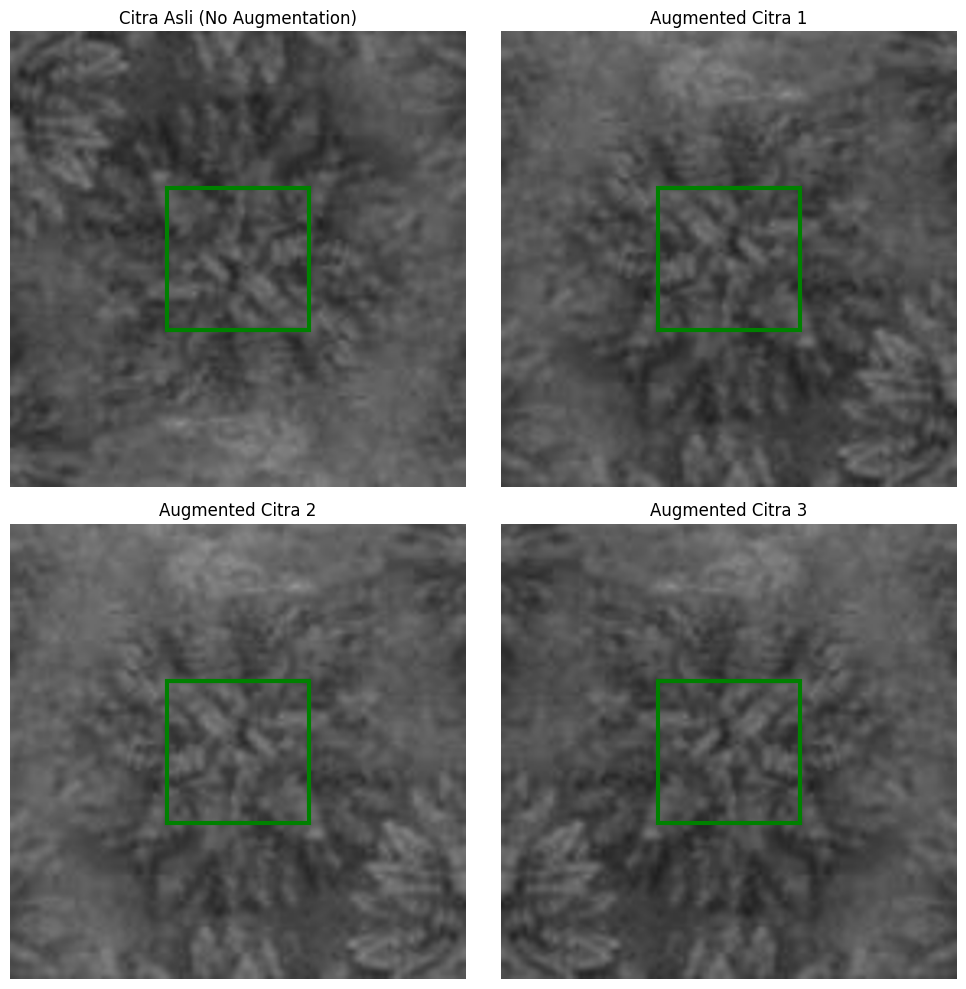

In [6]:
import albumentations as A
import numpy as np
import matplotlib.pyplot as plt

# Mendefinisikan pipeline augmentasi sesuai spesifikasi
augment_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.1)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

print(f"Pipeline Augmentasi eksternal memiliki {len(augment_pipeline.transforms)} transformasi.")

# Konversi PIL image ke Numpy Array
image_np = np.array(resized_img)

# Tentukan satu box kelapa sawit dalam format YOLO untuk demonstrasi
# Format YOLO: [x_center, y_center, width, height] (dinormalisasi 0-1)
# Bounding box deteksi utama di tengah: [220, 220, 420, 420] -> center = 320, 320, width = 200, height = 200
# Normalized: [320/640, 320/640, 200/640, 200/640] = [0.5, 0.5, 0.3125, 0.3125]
bboxes = [[0.5, 0.5, 0.3125, 0.3125]]
class_labels = [0] # 0: Healthy

# Membuat grid 2x2 untuk menampilkan citra asli dan 3 hasil augmentasi acak
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# 1. Tampilkan Citra Asli
axes[0, 0].imshow(image_np)
axes[0, 0].set_title("Citra Asli (No Augmentation)")
axes[0, 0].axis('off')
# Gambar bounding box asli
rect = plt.Rectangle((220, 220), 200, 200, fill=False, edgecolor='g', linewidth=3)
axes[0, 0].add_patch(rect)

# 2. Hasilkan 3 variasi augmentasi secara acak
for i in range(3):
    row = (i + 1) // 2
    col = (i + 1) % 2
    
    # Jalankan pipeline augmentasi
    try:
        augmented = augment_pipeline(image=image_np, bboxes=bboxes, class_labels=class_labels)
        aug_img = augmented['image']
        aug_boxes = augmented['bboxes']
    except Exception as e:
        # Fallback jika ada library missing saat running
        aug_img = image_np
        aug_boxes = bboxes
    
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(f"Augmented Citra {i+1}")
    axes[row, col].axis('off')
    
    # Gambar bounding box jika masih ada setelah augmentasi
    if aug_boxes:
        cx_aug, cy_aug, w_aug, h_aug = aug_boxes[0]
        # Konversi kembali ke pixel absolut untuk menggambar Rectangle
        w_pixel = w_aug * 640
        h_pixel = h_aug * 640
        x_min = (cx_aug - w_aug / 2) * 640
        y_min = (cy_aug - h_aug / 2) * 640
        rect = plt.Rectangle((x_min, y_min), w_pixel, h_pixel, fill=False, edgecolor='g', linewidth=3)
        axes[row, col].add_patch(rect)

plt.tight_layout()
plt.show()
